O Método da Secante é implementado abaixo. Ele recebe a função, dois chutes iniciais ($x_0$ e $x_1$), a tolerância de erro e o limite de iterações. A estrutura armazena os dados em listas e retorna um DataFrame do pandas para facilitar a visualização da tabela exigida na atividade.


In [9]:
# ==========================================
# PARTE 1 - IMPLEMENTAÇÃO DO MÉTODO DA SECANTE
# ==========================================
def secante(f, x0, x1, tol=1e-6, max_iter=50):
    resultados = []
    erros_hist = []

    # Registrando a iteração inicial
    erro = abs(x1 - x0)
    resultados.append({'Iteração': 1, 'x_n': x1, 'f(x_n)': f(x1), 'erro': erro})
    erros_hist.append(erro)

    iteracao = 2
    while erro > tol and iteracao <= max_iter:
        if f(x1) - f(x0) == 0:
            print("Erro: Divisão por zero no método da secante.")
            break

        # Fórmula da Secante
        x_next = x1 - f(x1) * (x1 - x0) / (f(x1) - f(x0))
        erro = abs(x_next - x1)
        erros_hist.append(erro)

        resultados.append({
            'Iteração': iteracao,
            'x_n': x_next,
            'f(x_n)': f(x_next),
            'erro': erro
        })

        x0 = x1
        x1 = x_next
        iteracao += 1

    df_resultados = pd.DataFrame(resultados)
    return x1, df_resultados, iteracao - 1, erros_hist

Parte 3 — Escolha da Função e Preparação
Para esta análise, a Função 1 ($f(x) = x^3 - x - 2$) foi escolhida. O primeiro passo é importar as bibliotecas necessárias para os cálculos, estruturação de tabelas e geração de gráficos, além de declarar a função e sua derivada (que será usada posteriormente no Método de Newton).

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# PARTE 3 - DEFINIÇÃO DA FUNÇÃO
# ==========================================
def f(x):
    return x**3 - x - 2

# Derivada analítica (necessária apenas para o Método de Newton)
def df(x):
    return 3*x**2 - 1

Parte 4 — Implementação dos Métodos Auxiliares para Comparação
Para comparar a eficiência do Método da Secante, implementamos também o Método da Bissecção e o Método de Newton. Cada função retorna a raiz encontrada, o número de iterações necessárias para a convergência e o histórico de erros.

In [11]:
# ==========================================
# IMPLEMENTAÇÃO DA BISSECÇÃO E NEWTON
# ==========================================
def bisseccao(f, a, b, tol=1e-6, max_iter=50):
    erros_hist = []
    if f(a) * f(b) >= 0:
        return None, 0, []

    iteracao = 0
    erro = abs(b - a)
    while erro > tol and iteracao < max_iter:
        c = (a + b) / 2.0
        erro = abs(b - a) / 2.0
        erros_hist.append(erro)

        if f(c) == 0 or erro < tol:
            return c, iteracao + 1, erros_hist

        if f(a) * f(c) < 0:
            b = c
        else:
            a = c
        iteracao += 1
    return c, iteracao, erros_hist

def newton(f, df, x0, tol=1e-6, max_iter=50):
    erros_hist = []
    iteracao = 0
    erro = 1.0 # Valor inicial

    while erro > tol and iteracao < max_iter:
        if df(x0) == 0:
            break
        x1 = x0 - f(x0) / df(x0)
        erro = abs(x1 - x0)
        erros_hist.append(erro)
        x0 = x1
        iteracao += 1
    return x0, iteracao, erros_hist

Execução dos Testes e Tabela de Comparação
Agora, definimos os parâmetros de tolerância e os valores iniciais para cada método. Executamos as três funções e imprimimos as tabelas com os resultados da Secante e a comparação de iterações entre os três métodos.

In [12]:
# ==========================================
# EXECUÇÃO DOS MÉTODOS E EXIBIÇÃO DAS TABELAS
# ==========================================

# Parâmetros
TOL = 1e-6
x_inicial_newton = 2.0
a_bissec, b_bissec = 1.0, 2.0
x0_sec, x1_sec = 1.0, 2.0

# Executando os métodos
raiz_sec, df_sec, iters_sec, erros_sec = secante(f, x0_sec, x1_sec, TOL)
raiz_bissec, iters_bissec, erros_bissec = bisseccao(f, a_bissec, b_bissec, TOL)
raiz_newton, iters_newton, erros_newton = newton(f, df, x_inicial_newton, TOL)

print("--- TABELA DO MÉTODO DA SECANTE ---")
display(df_sec) # No Colab, 'display' renderiza a tabela bem formatada

print("\n--- COMPARAÇÃO DE MÉTODOS ---")
df_comparacao = pd.DataFrame({
    'Método': ['Bissecção', 'Newton', 'Secante'],
    'Iterações até convergir': [iters_bissec, iters_newton, iters_sec]
})
display(df_comparacao)

--- TABELA DO MÉTODO DA SECANTE ---


,Iteração,x_n,f(x_n),erro
0,1,2.000000,4.000000e+00,1.000000e+00
1,2,1.333333,-9.629630e-01,6.666667e-01
2,3,1.462687,-3.333389e-01,1.293532e-01
3,4,1.531169,5.862642e-02,6.848286e-02
4,5,1.520926,-2.693300e-03,1.024301e-02
5,6,1.521376,-2.015019e-05,4.498962e-04
6,7,1.521380,7.015478e-09,3.391315e-06
7,8,1.521380,-1.842970e-14,1.180307e-09



--- COMPARAÇÃO DE MÉTODOS ---


,Método,Iterações até convergir
0,Bissecção,20
1,Newton,5
2,Secante,8


Desafio Extra — Velocidade de Convergência
O gráfico abaixo ilustra a velocidade de convergência de cada método, plotando a queda do erro a cada iteração em uma escala logarítmica.

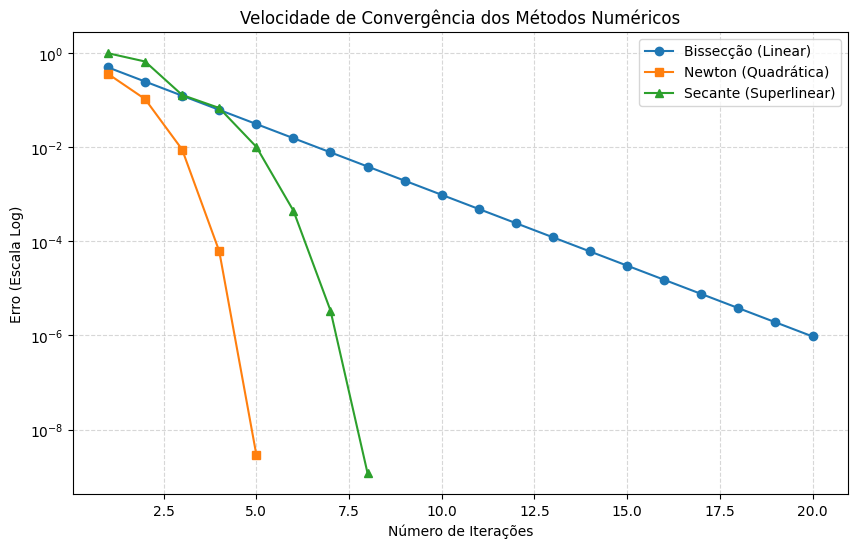

In [13]:
# ==========================================
# DESAFIO EXTRA - GRÁFICO DE CONVERGÊNCIA
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(erros_bissec)+1), erros_bissec, marker='o', label='Bissecção (Linear)')
plt.plot(range(1, len(erros_newton)+1), erros_newton, marker='s', label='Newton (Quadrática)')
plt.plot(range(1, len(erros_sec)+1), erros_sec, marker='^', label='Secante (Superlinear)')

plt.yscale('log') # Escala logarítmica evidencia a queda brusca do erro
plt.xlabel('Número de Iterações')
plt.ylabel('Erro (Escala Log)')
plt.title('Velocidade de Convergência dos Métodos Numéricos')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

# Parte 5 — Investigação (Respostas)

# 1. Qual método convergiu mais rapidamente?
O Método de Newton convergiu mais rapidamente, exigindo o menor número de iterações, devido à sua convergência quadrática. O Método da Secante ficou em segundo lugar (convergência superlinear), seguido pela Bissecção (convergência linear).
# 2. A secante sempre converge?
Teste com diferentes valores iniciais.Não, a convergência não é garantida. Se os valores iniciais $x_0$ e $x_1$ estiverem muito distantes da raiz real ou em uma região onde a curva muda de direção drasticamente, a reta secante pode jogar a próxima aproximação para muito longe, fazendo o método divergir.
# 3. Em quais situações o método da secante pode falhar?
A principal falha ocorre por divisão por zero. Se durante o processo encontrarmos dois pontos onde $f(x_n) = f(x_{n-1})$, a reta secante será horizontal, tornando impossível calcular a interseção com o eixo x. Também falha se os pontos iniciais estiverem perto de um ponto de máximo ou mínimo local da função.
# 4. Compare a necessidade de informação adicional entre os métodos:
Bissecção: Requer apenas a própria função $f(x)$ e um intervalo $[a, b]$ que contenha uma troca de sinal (garantindo a existência da raiz).

Newton: Requer a função $f(x)$, apenas um chute inicial $x_0$, mas exige conhecer e calcular a derivada analítica da função $f'(x)$.

Secante: Requer a função $f(x)$ e dois chutes iniciais ($x_0$ e $x_1$), mas dispensa o cálculo da derivada.

# 5. Se você estivesse desenvolvendo um software de engenharia para encontrar raízes de funções desconhecidas, qual método escolheria e por quê?
Para um software robusto em engenharia, a escolha ideal seria o Método da Secante (ou métodos híbridos baseados nele, como o de Brent). Em problemas reais, as funções muitas vezes resultam de simulações complexas ou dados experimentais, onde calcular a derivada (exigida por Newton) é muito custoso computacionalmente ou matematicamente impossível. A Secante oferece uma velocidade excelente sem precisar dessa informação extra.